# 🔗 Pairs trading: Gatev–Goetzmann–Rouwenhorst-style relative value

## 🧭 tl;dr

This notebook tests a simple market-neutral pairs trade: buy the relatively cheap member of a historically related pair and short the relatively expensive member when their price spread becomes unusually wide.

> Educational research only. This notebook is not financial advice.

<div style="border-left: 5px solid #2563EB; padding: 0.85em 1em; margin: 1em 0 1.4em; background: #F8FAFC; border-radius: 8px;">
<strong>🧭 Reader guide</strong><br>
Read from top to bottom: understand the economic idea, inspect the exact rule, then compare the formal test results with the robustness checks. Finish with <strong>What went well / what went wrong</strong> to see why a backtest is evidence—not proof.
</div>

## 🧭 Context & methods

Pairs trading is a relative-value strategy. It does not ask whether the whole market will rise; it asks whether two related securities will move back toward a historical relationship. The pair used here is KO and PEP, chosen as an intuitive consumer-staples example—not because the paper used these securities.

### 🔧 Key assumptions

- Pair: KO versus PEP, with SPY as the directional benchmark.
- A rolling return-based hedge ratio estimates how much of the second asset offsets the first.
- Entry occurs when the spread z-score exceeds ±2; exit occurs when it returns inside ±0.5.
- The backtester shifts weights by one bar and charges 10 bps on absolute weight changes.

In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'src').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))

from src.backtest import run_backtest, split_time_series
from src.data import load_price_panel, make_demo_ohlcv
from src.portfolio import (
    dual_momentum_weights,
    inverse_volatility_weights,
    minimum_variance_weights,
    run_portfolio_backtest,
)
from src.research import metrics_for_period

# Consistent visual language across the research library.
plt.rcParams.update({
    "figure.figsize": (12, 5),
    "figure.dpi": 120,
    "savefig.dpi": 160,
    "axes.facecolor": "#F8FAFC",
    "axes.edgecolor": "#CBD5E1",
    "axes.grid": True,
    "grid.color": "#CBD5E1",
    "grid.alpha": 0.35,
    "axes.titleweight": "bold",
    "axes.titlesize": 14,
    "axes.labelcolor": "#334155",
    "xtick.color": "#475569",
    "ytick.color": "#475569",
    "legend.frameon": False,
    "figure.autolayout": True,
})


## 📦 Data

The notebook uses adjusted daily closes when available. Missing assets are removed through a common-date intersection; if the download fails, deterministic demo data keeps the code path testable without pretending the synthetic results are market evidence.

In [2]:
USE_DEMO_DATA = False
TRANSACTION_COST_BPS = 10
TICKERS = ['KO', 'PEP', 'SPY']

if USE_DEMO_DATA:
    close = pd.concat([make_demo_ohlcv(periods=5_000, seed=120, start='2006-01-01')['close'].rename(t), make_demo_ohlcv(periods=5_000, seed=121, start='2006-01-01')['close'].rename(t), make_demo_ohlcv(periods=5_000, seed=122, start='2006-01-01')['close'].rename(t)], axis=1)
else:
    try:
        close = load_price_panel(TICKERS, '2010-01-01', '2026-01-01')
    except Exception as exc:
        print(f'Live download unavailable ({type(exc).__name__}: {exc}); using deterministic demo data.')
        close = pd.concat([make_demo_ohlcv(periods=5_000, seed=120, start='2006-01-01')['close'].rename(t), make_demo_ohlcv(periods=5_000, seed=121, start='2006-01-01')['close'].rename(t), make_demo_ohlcv(periods=5_000, seed=122, start='2006-01-01')['close'].rename(t)], axis=1)

close = close.dropna(how='any')
splits = split_time_series(close, train_fraction=0.60, validation_fraction=0.20)
benchmark_returns = close['SPY'].pct_change().fillna(0.0)
print(f'Data: {close.index.min().date()} through {close.index.max().date()} ({len(close):,} common trading days)')
print('Assets:', ', '.join(close.columns))


Data: 2010-01-04 through 2025-12-31 (4,024 common trading days)
Assets: KO, PEP, SPY


## 📜 Strategy rules

- **Long spread:** when KO is unusually cheap relative to PEP.
- **Short spread:** when KO is unusually expensive relative to PEP.
- **Exit:** close both legs when the spread normalizes.
- **Sizing:** scale the two legs so gross exposure is approximately 1.0.

This is a deliberately small, inspectable example of relative-value trading. Real pairs books select and monitor many pairs, manage borrow and liquidity, and respond to structural breaks.

In [3]:
def pair_trading_weights(panel, first='KO', second='PEP', lookback=60, entry_z=2.0, exit_z=0.5):
    log_prices = np.log(panel[[first, second]])
    log_returns = log_prices.diff()
    hedge_beta = (
        log_returns[first].rolling(lookback).cov(log_returns[second])
        / log_returns[second].rolling(lookback).var()
    ).shift(1)
    spread = log_prices[first] - hedge_beta * log_prices[second]
    center = spread.rolling(lookback).mean()
    scale = spread.rolling(lookback).std(ddof=1).replace(0.0, np.nan)
    z_score = (spread - center) / scale

    weights = pd.DataFrame(0.0, index=panel.index, columns=panel.columns)
    state = 0.0
    for timestamp in panel.index:
        z = z_score.loc[timestamp]
        beta = hedge_beta.loc[timestamp]
        if pd.notna(z):
            if state == 0.0 and z < -entry_z:
                state = 1.0
            elif state == 0.0 and z > entry_z:
                state = -1.0
            elif state != 0.0 and abs(z) < exit_z:
                state = 0.0
        if pd.notna(beta) and state != 0.0:
            normalizer = 1.0 + abs(float(beta))
            weights.loc[timestamp, first] = state / normalizer
            weights.loc[timestamp, second] = -state * float(beta) / normalizer
    return weights.ffill().fillna(0.0), z_score

weights, spread_z = pair_trading_weights(close)


## 📈 Formal test results

The untouched final 20% of the chronological sample is used for the headline table. Parameters are defined before reading the final test outputs.

In [4]:
result = run_portfolio_backtest(
    close if 'weights' in locals() and set(weights.columns) == set(close.columns) else close,
    weights,
    transaction_cost_bps=TRANSACTION_COST_BPS,
    benchmark_returns=benchmark_returns,
)
test_metrics = metrics_for_period(result, splits['test'].index)
test_table = pd.DataFrame([test_metrics], index=['Pairs trading: Gatev–Goetzmann–Rouwenhorst-style relative value'])
format_map = {
    'annualized_return': '{:.2%}', 'annualized_volatility': '{:.2%}', 'sharpe_ratio': '{:.2f}',
    'sortino_ratio': '{:.2f}', 'max_drawdown': '{:.2%}', 'calmar_ratio': '{:.2f}',
    'win_rate': '{:.2%}', 'annualized_turnover': '{:.2f}', 'number_of_trades': '{:.0f}',
    'total_return_after_costs': '{:.2%}', 'benchmark_relative_return': '{:.2%}',
}
display(test_table.style.format(format_map))
print('Formal test findings:')
print(f"  Sharpe={test_metrics['sharpe_ratio']:.2f} | annualized return={test_metrics['annualized_return']:.2%} | max drawdown={test_metrics['max_drawdown']:.2%}")


,annualized_return,annualized_volatility,sharpe_ratio,sortino_ratio,max_drawdown,calmar_ratio,win_rate,annualized_turnover,number_of_trades,total_return_after_costs,benchmark_total_return,benchmark_relative_return
Pairs trading: Gatev–Goetzmann–Rouwenhorst-style relative value,7.43%,5.56%,1.32,2.15,-6.70%,1.11,53.61%,8.58,510,25.74%,0.992718,-73.53%


Formal test findings:
  Sharpe=1.32 | annualized return=7.43% | max drawdown=-6.70%


## 📊 Equity curve and drawdown

The chart normalizes the strategy and SPY benchmark to one at the start of the formal test period. Drawdown is shown below it so a smooth return path is not mistaken for low risk.

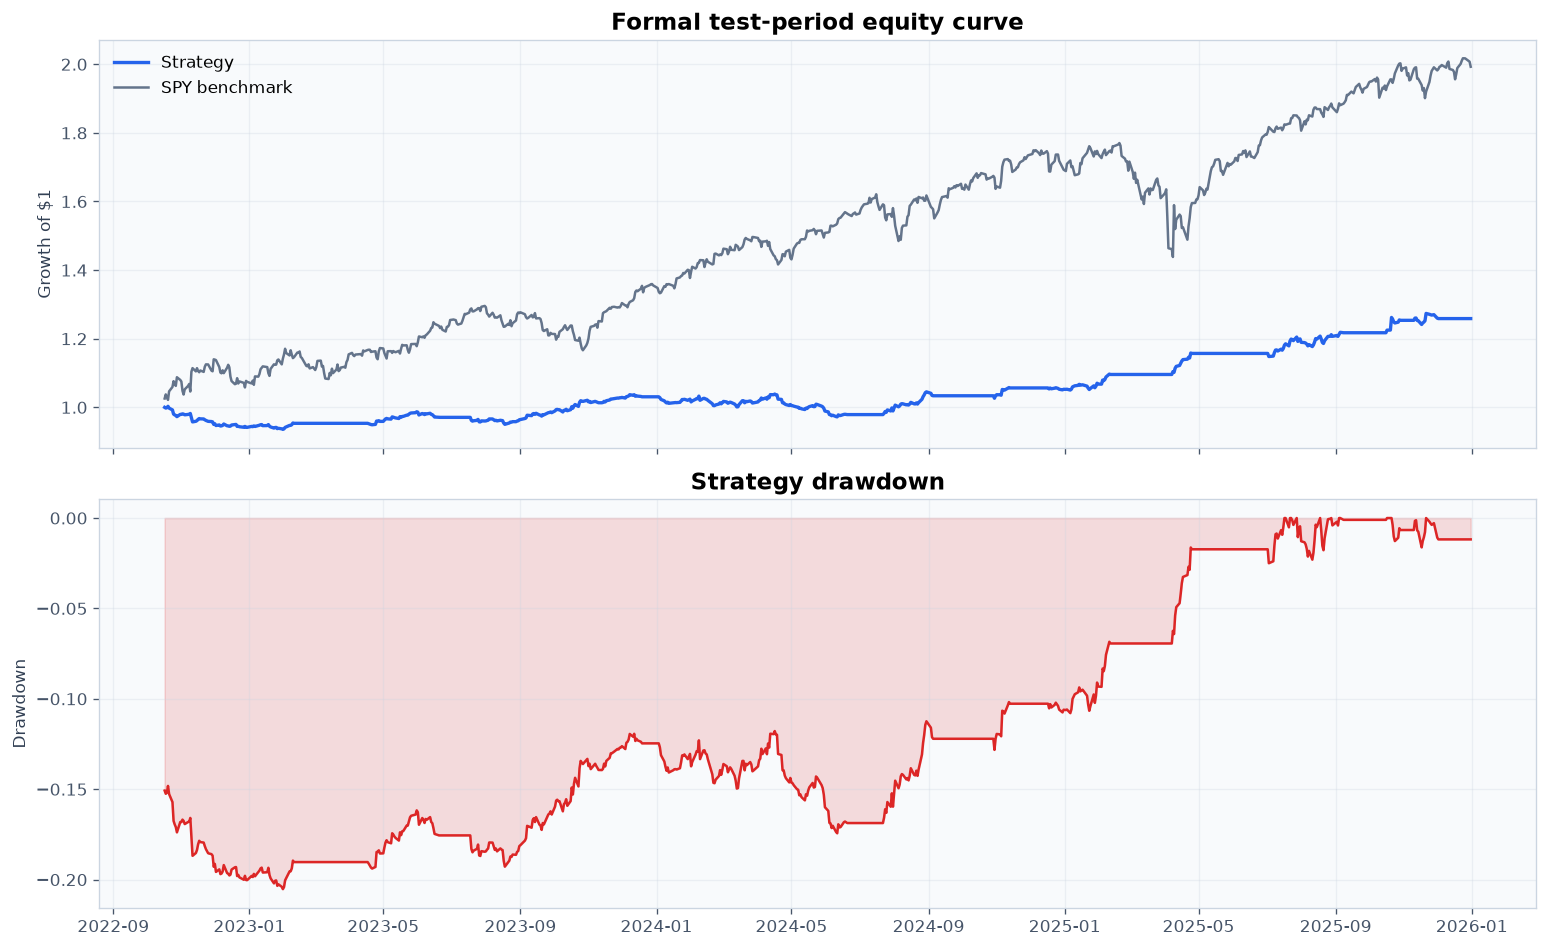

In [5]:
test_index = splits['test'].index
equity = result.frame.loc[test_index, 'equity']
fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)
axes[0].plot(equity.index, equity / equity.iloc[0], color='#2563EB', linewidth=2, label='Strategy')
benchmark_curve = (1.0 + result.frame.loc[test_index, 'benchmark_returns']).cumprod()
axes[0].plot(benchmark_curve.index, benchmark_curve, color='#64748B', linewidth=1.5, label='SPY benchmark')
axes[0].set_title('Formal test-period equity curve')
axes[0].set_ylabel('Growth of $1')
axes[0].legend()
axes[0].grid(alpha=0.3)
drawdown = result.frame.loc[test_index, 'drawdown']
axes[1].plot(drawdown.index, drawdown, color='#DC2626', linewidth=1.5)
axes[1].fill_between(drawdown.index, drawdown, 0, color='#DC2626', alpha=0.15)
axes[1].set_title('Strategy drawdown')
axes[1].set_ylabel('Drawdown')
axes[1].grid(alpha=0.3)
plt.show()


## 🛡️ Robustness and crisis diagnostics

These checks are descriptive. Cost sensitivity shows how much implementation friction matters; crisis windows show failure modes and are not additional untouched test sets.

In [6]:
cost_rows = []
for cost_bps in [0, 5, 10, 25, 50]:
    candidate = run_candidate(cost_bps) if 'run_candidate' in locals() else None
    if candidate is None:
        if 'weights' in locals():
            candidate = run_portfolio_backtest(close, weights, transaction_cost_bps=cost_bps, benchmark_returns=benchmark_returns)
        else:
            candidate = run_backtest(close.iloc[:, 0], target, transaction_cost_bps=cost_bps, benchmark_returns=benchmark_returns)
    metrics = metrics_for_period(candidate, splits['test'].index)
    cost_rows.append({'cost_bps': cost_bps, 'test_return': metrics['annualized_return'], 'test_sharpe': metrics['sharpe_ratio'], 'max_drawdown': metrics['max_drawdown'], 'turnover': metrics['annualized_turnover']})
cost_table = pd.DataFrame(cost_rows).set_index('cost_bps')
display(cost_table.style.format({'test_return': '{:.2%}', 'test_sharpe': '{:.2f}', 'max_drawdown': '{:.2%}', 'turnover': '{:.2f}'}))

stress_windows = {
    'Global Financial Crisis': ('2007-10-01', '2009-03-31'),
    'COVID shock': ('2020-02-19', '2020-03-23'),
    '2022 inflation/rates shock': ('2022-01-03', '2022-10-14'),
}
stress_rows = []
for window, (start, end) in stress_windows.items():
    index = close.loc[start:end].index
    if len(index) == 0:
        continue
    returns = result.frame.loc[index, 'net_returns']
    path = (1.0 + returns).cumprod()
    stress_rows.append({'window': window, 'return': path.iloc[-1] - 1.0, 'max_drawdown': (path / path.cummax() - 1.0).min()})
stress_table = pd.DataFrame(stress_rows).set_index('window')
display(stress_table.style.format({'return': '{:.2%}', 'max_drawdown': '{:.2%}'}))


,test_return,test_sharpe,max_drawdown,turnover
cost_bps,,,,
0,8.36%,1.48,-6.66%,8.58
5,7.90%,1.40,-6.68%,8.58
10,7.43%,1.32,-6.70%,8.58
25,6.06%,1.08,-6.76%,8.58
50,3.80%,0.68,-7.43%,8.58


,return,max_drawdown
window,,
COVID shock,-1.01%,-4.36%
2022 inflation/rates shock,-3.31%,-3.75%


## ⚖️ What went well / what went wrong

**What went well:** The pair trade is naturally close to market-neutral, has an intuitive entry/exit story, and makes the effect of hedge-ratio and spread assumptions visible.

**What went wrong:** A historical relationship can break permanently. The test uses one hand-selected pair, ignores borrow fees, dividends, short-sale constraints, corporate actions, and pair-selection bias; apparent convergence can also be a value trap.

**Research judgment:** Pairs trading can look attractive before realistic shorting and execution costs. The core research question is whether the relationship remains stable out of sample.

> The displayed metrics are sample-specific proxy results. They should be interpreted alongside costs, turnover, stress windows, and implementation gaps.